<a href="https://colab.research.google.com/github/ayse50/PyTorch/blob/main/casting_product.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Qualitätskontrolle von Gussteilen

### Problem
 Die manuelle Inspektion von Gussteilen ist zeitaufwendig, fehleranfällig und führt durch menschliche Ungenauigkeit zu wirtschaftlichen Verlusten.


### Lösung
Entwicklung eines Deep Learning Modells zu binären Klassifikation mithilfe von PyTorch, um die Inspektionsprozesse zu automatisieren und somit zu erleichtern.


### Datensatz
*   Inhalt: Graustufenbilder von Pumpen-Impellern
*   Klassen: 2 (Defekt vs. Ok)





## 1. Daten Laden und Visualisieren

### Daten von Kaggle laden

In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:

import opendatasets as od
dataset_url = 'https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product'
od.download(dataset_url)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: "ayseguelk"
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product


100%|██████████| 100M/100M [00:00<00:00, 119MB/s] 


### Pfade zu den bereits existierenden Datensets festlegen

In [3]:
import os

base_path = '/content/real-life-industrial-dataset-of-casting-product/casting_data/casting_data'
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
train_ok_dir = os.path.join(train_dir, 'ok_front' )
train_def_dir = os.path.join(train_dir, 'def_front' )
test_ok_dir = os.path.join(test_dir, 'ok_front' )
test_def_dir = os.path.join(test_dir, 'def_front' )


### Visualisierung der Datenaufteilung

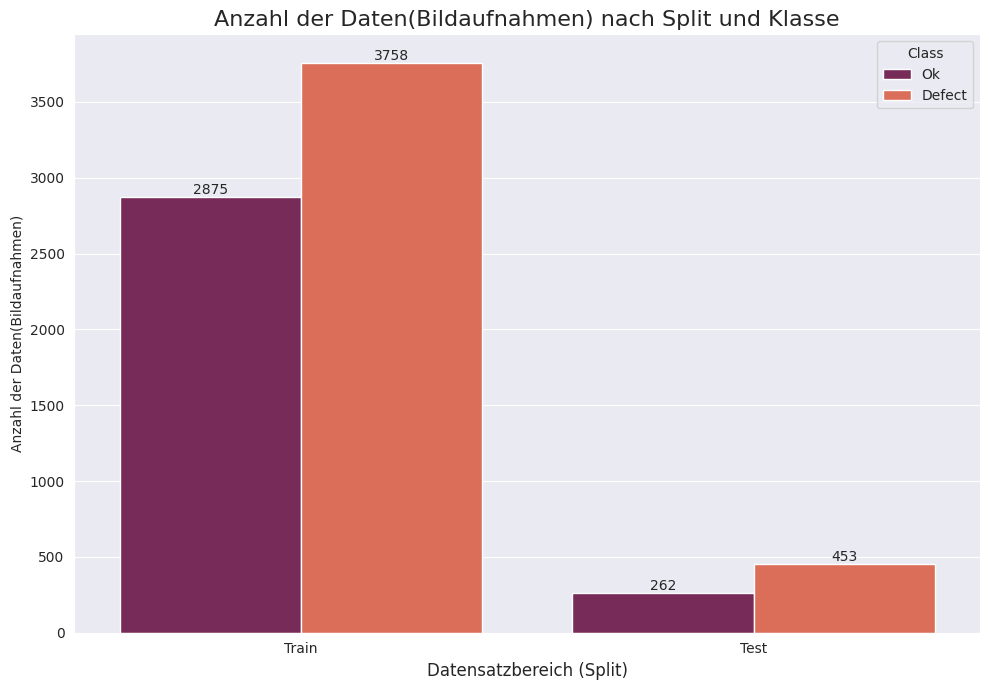

In [4]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Zählen der Daten
train_def = len(os.listdir(train_def_dir))
train_ok = len(os.listdir(train_ok_dir))
test_def = len(os.listdir(test_def_dir))
test_ok = len(os.listdir(test_ok_dir))

# Erstellen eines Dataframes  mit den Test und train daten
daten = {'Teilung': ['Train', 'Train', 'Test', 'Test'],
         'Class': ['Ok', 'Defect', 'Ok', 'Defect'],
         'Anzahl': [train_ok, train_def, test_ok, test_def]}

df = pd.DataFrame(daten)

#Visualisierung der Aufteilung der Daten
sns.set_style('darkgrid')
plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Teilung', y='Anzahl', hue='Class', data=df, palette="rocket")
plt.title('Anzahl der Daten(Bildaufnahmen) nach Split und Klasse', fontsize=16)
plt.xlabel('Datensatzbereich (Split)', fontsize=12)
plt.ylabel('Anzahl der Daten(Bildaufnahmen)')

for container in ax.containers:
  ax.bar_label(container)

plt.tight_layout()
plt.show()


In [5]:
print(f'Verhältnis im Training:{train_ok / train_def:.2f} (Ok zu Defekt)')
print(f'Verhältnis im Test:{test_ok / test_def:.2f} (Ok zu Defekt)')

Verhältnis im Training:0.77 (Ok zu Defekt)
Verhältnis im Test:0.58 (Ok zu Defekt)


### Verhältnisse in den Sets sind recht ausgewogen.

## 2. Daten vorbereiten

In [6]:
import torch
import torchvision
from torchvision import transforms, datasets
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np

SEED = 42
torch.manual_seed(SEED)

#Bilder in Tensor umwandeln und normalisieren
transform_img_trn = transforms.Compose([transforms.Resize((224, 224)),
                                        transforms.Grayscale(num_output_channels=1),
                                        transforms.RandomRotation(15),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.RandomVerticalFlip(),
                                        transforms.ColorJitter(brightness=0.3, contrast=0.3),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean=[0.5], std=[0.5])])

transform_img_tst = transforms.Compose([transforms.Resize((224, 224)),
                                        transforms.Grayscale(num_output_channels=1),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean=[0.5], std=[0.5])])

train_set = datasets.ImageFolder(root='/content/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train', transform=transform_img_trn)
test_set =datasets.ImageFolder(root='/content/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test', transform=transform_img_tst)

#Dataloader
BATCH_SIZE = 32

train_dataloader= DataLoader(train_set,
                             batch_size=BATCH_SIZE,
                             shuffle = True)


test_dataloader= DataLoader(test_set,
                             batch_size=BATCH_SIZE,
                             shuffle = False)


print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7faa19d21a30>, <torch.utils.data.dataloader.DataLoader object at 0x7faa0c98b290>)
Length of train dataloader: 208 batches of 32
Length of test dataloader: 23 batches of 32


In [7]:
images, labels = next(iter(train_dataloader))
class_names = train_set.classes
images.shape, labels.shape

(torch.Size([32, 1, 224, 224]), torch.Size([32]))

### Anzeigen von 4 zufälligen Bildern aus dem Trainingsset (4 Sample)
#### es dient zur Kontrolle, um zu sehen in welchem Zustand sich die Bilder für das Trainiren der Modelle befindet.


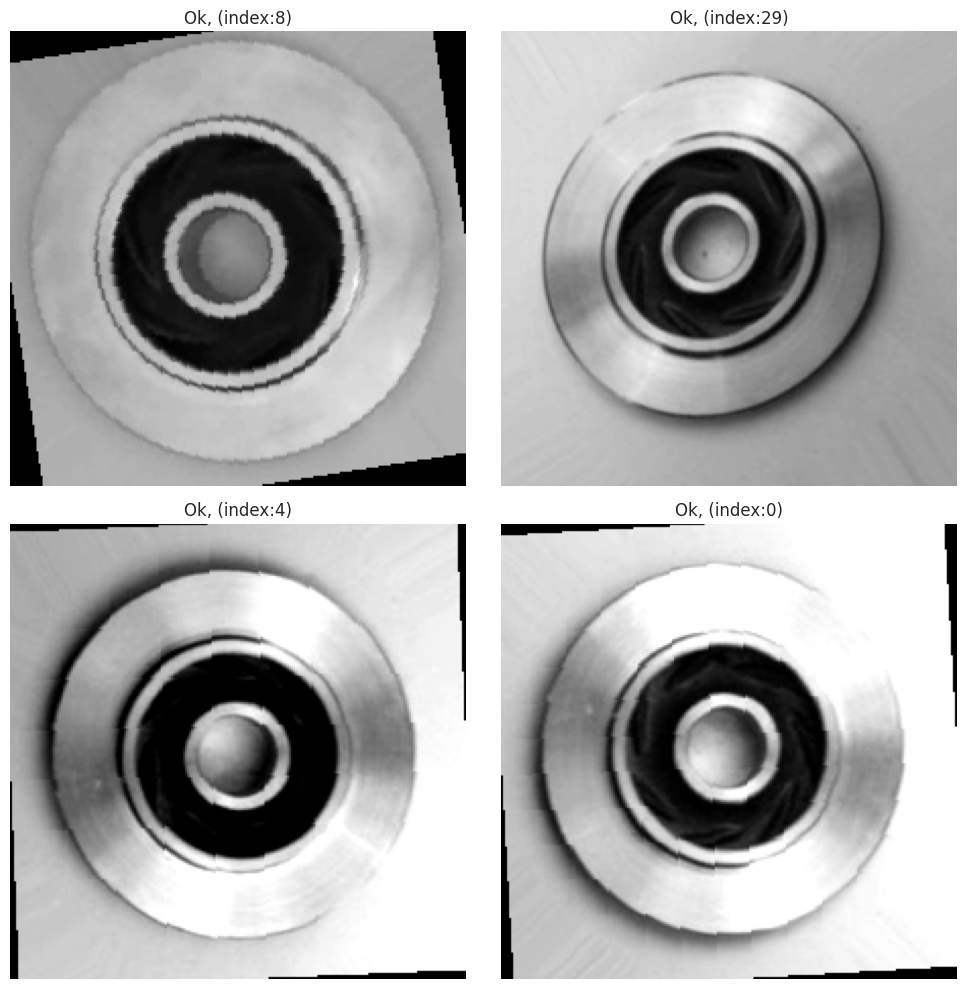

In [8]:

fig, axes = plt.subplots(2,2, figsize=(10,10))
random_idx = torch.randint(0, len(images), size=[4])
axes = axes.flatten()

for i, idx in enumerate(random_idx):
  img = images[idx]
  label = labels[idx].item()

  name = class_names[label]
  if 'ok' in name.lower():
    uberschrift = 'Ok'
  else:
    uberschrift = 'Defekt'

  axes[i].imshow(img.squeeze(), cmap=('gray'))
  axes[i].set_title(f'{uberschrift}, (index:{idx.item()})')
  axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Model, Loss Funktion, Optimizer, training loop and predictions for Baseline-Model

Zuerst ein Baseline Model aufbauen um weitere Modelle damit vergleichen zu können.

Für Baseline Model das simpelste nehmen: --> Hier Baseline Modell besteht aus zwei nn.Linear() Layern.

In [15]:
import torch
from torch import nn

# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else'cpu'


flatten_model = nn.Flatten()
x = images[0]
output = flatten_model(x)

print(f'Form bevor flattening: {x.shape}')
print(f'Form nach flattening: {output.shape}')


Form bevor flattening: torch.Size([1, 224, 224])
Form nach flattening: torch.Size([1, 50176])


### Baseline-Model (model_0)

In [16]:

class ModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)


# Setup model with Parameters
torch.manual_seed(42)

model_0 = ModelV0(input_shape= 50176,
                  hidden_units= 10,
                  output_shape= 2)
model_0.to(device)
print('Model setup on device:', {device})

next(model_0.parameters()).device

Model setup on device: {'cuda'}


device(type='cuda', index=0)

#### Setup loss, optimizer and evaluation metrics

In [17]:
import requests
from pathlib import Path

# download Helper functions from Learn PyTorch repo
if Path('helper:functions.py').is_file():
  print('helper_functions.py already exists, skipping download...')
else:
  print('Downloading helper_functions.py')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
  with open('helper_functions.py','wb') as f: # wb= write binary, f=file
    f.write(request.content)


In [34]:
# accuracy metric
from helper_functions import accuracy_fn

# loss function
loss_fn = nn.CrossEntropyLoss()

#optimizer
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)


In [35]:
# function for timing the experiment
from timeit import default_timer as timer
def train_time(start: float, end:float, device: torch.device = None):
  total_time = end -start
  print(f'Train time on {device}: {total_time:.3f} seconds')
  return total_time


### Creating training/ testing loop & training Baseline-Model (with progress bar)

Functions for the loops

In [52]:
#Funktion für das Training
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true = y,
                             y_pred = y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f'\nTrain loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%')

#Funktion für den Test
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true = y,
                              y_pred=test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f'\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%')


In [53]:
from tqdm.auto import tqdm
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start = timer()
epochs = 5

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n---------')
  train_step(model= model_0,
             data_loader= train_dataloader,
             loss_fn= loss_fn,
             optimizer= optimizer,
             accuracy_fn = accuracy_fn,
             device=device)
  test_step(model= model_0,
            data_loader= test_dataloader,
            loss_fn= loss_fn,
            accuracy_fn = accuracy_fn,
            device=device)

train_time_end = timer()
total_train_time_model_0 = train_time(start = train_time_start,
                                      end = train_time_end,
                                      device = device)


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------

Train loss: 0.24884 | Train accuracy: 87.29%

Test loss: 0.24171 | Test accuracy: 87.80%
Epoch: 1
---------

Train loss: 0.25151 | Train accuracy: 87.68%

Test loss: 0.24171 | Test accuracy: 87.80%
Epoch: 2
---------

Train loss: 0.24812 | Train accuracy: 87.48%

Test loss: 0.24171 | Test accuracy: 87.80%
Epoch: 3
---------

Train loss: 0.24307 | Train accuracy: 87.91%

Test loss: 0.24171 | Test accuracy: 87.80%
Epoch: 4
---------

Train loss: 0.25456 | Train accuracy: 87.30%

Test loss: 0.24171 | Test accuracy: 87.80%
Train time on cuda: 112.077 seconds


### Predictions and results for Baseline model

In [54]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):


  loss , acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return{'model_name': model.__class__.__name__,
           'model_loss': loss.item(),
           'model_acc': acc}



###Results of Baseline-Model

In [55]:
model_0_result = eval_model(model_0, data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn,
                            device = device)

model_0_result

{'model_name': 'ModelV0',
 'model_loss': 0.2417079508304596,
 'model_acc': 87.79644268774703}

## 4. Model, Loss Funktion, Optimizer, training loop and predictions for model_1 (CNN)

###model_1 (CNN)

In [56]:
class ModelV1(nn.Module):
  def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
    super().__init__()

    # Block 1 findet einfache Muster (Kanten, Linien)
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels= input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    # Block 2 findet komplexere Formen(Kreise, Risse)
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    # Classifier wandelt räumliche Daten in Klassen um
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*56*56,
                  out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model_1 = ModelV1(input_shape=1,
                  hidden_units=10,
                  output_shape=2).to(device)

model_1

ModelV1(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=31360, out_features=2, bias=True)
  )
)

###Setup loss and  optimizer for model_1

In [60]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

### training and testing loop for model_1

In [61]:
from tqdm.auto import tqdm
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start = timer()
epochs = 4

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n---------')
  train_step(model= model_1,
             data_loader= train_dataloader,
             loss_fn= loss_fn,
             optimizer= optimizer,
             accuracy_fn = accuracy_fn,
             device=device)

  test_step(model= model_1,
            data_loader= test_dataloader,
            loss_fn= loss_fn,
            accuracy_fn = accuracy_fn,
            device=device)

train_time_end = timer()
total_train_time_model_1 = train_time(start = train_time_start,
                                      end = train_time_end,
                                      device = device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------

Train loss: 0.09985 | Train accuracy: 96.72%

Test loss: 0.05478 | Test accuracy: 98.64%
Epoch: 1
---------

Train loss: 0.08262 | Train accuracy: 97.57%

Test loss: 0.06399 | Test accuracy: 97.83%
Epoch: 2
---------

Train loss: 0.06867 | Train accuracy: 97.87%

Test loss: 0.04001 | Test accuracy: 98.64%
Epoch: 3
---------

Train loss: 0.06781 | Train accuracy: 98.18%

Test loss: 0.03739 | Test accuracy: 98.78%
Train time on cuda: 98.369 seconds


###Prediction and results for model_1

In [62]:
model_1_result = eval_model(model_1, data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn,
                            device = device)

model_1_result

{'model_name': 'ModelV1',
 'model_loss': 0.037391502410173416,
 'model_acc': 98.77717391304348}

## 5. Model, Loss Funktion, Optimizer, training loop and predictions for model_2

###model_2 (ResNet18)

In [68]:
from torchvision import models
from torch import nn

model_2 = models.resnet18(weights= 'DEFAULT')
model_2.conv1 = nn.Conv2d(1, 64, kernel_size = 7, stride=2, padding=3, bias=False)
in_features =model_2.fc.in_features
model_2.fc = nn.Linear(in_features, 2)
model_2= model_2.to(device)

###Setup loss and  optimizer for model_2

In [69]:
loss_fn = nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_2.parameters(), lr=0.0001)

### training and testing loop for model_2

In [70]:
from tqdm.auto import tqdm
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start = timer()
epochs = 4

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n---------')
  train_step(model= model_2,
             data_loader= train_dataloader,
             loss_fn= loss_fn,
             optimizer= optimizer,
             accuracy_fn = accuracy_fn,
             device=device)

  test_step(model= model_2,
            data_loader= test_dataloader,
            loss_fn= loss_fn,
            accuracy_fn = accuracy_fn,
            device=device)

train_time_end = timer()
total_train_time_model_2 = train_time(start = train_time_start,
                                      end = train_time_end,
                                      device = device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------

Train loss: 0.14734 | Train accuracy: 93.93%

Test loss: 0.06933 | Test accuracy: 97.16%
Epoch: 1
---------

Train loss: 0.66969 | Train accuracy: 62.23%

Test loss: 0.61284 | Test accuracy: 62.50%
Epoch: 2
---------

Train loss: 0.35446 | Train accuracy: 83.49%

Test loss: 0.10374 | Test accuracy: 95.65%
Epoch: 3
---------

Train loss: 0.06966 | Train accuracy: 97.66%

Test loss: 0.03086 | Test accuracy: 98.78%
Train time on cuda: 115.931 seconds


###Prediction and results for model_2

In [71]:
model_2_result = eval_model(model_2, data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn,
                            device = device)

model_2_result

{'model_name': 'ResNet',
 'model_loss': 0.030857546254992485,
 'model_acc': 98.77717391304348}

## Compare model results and training time

In [73]:
import pandas as pd
compare = pd.DataFrame([model_0_result, model_1_result, model_2_result])
compare['training_time'] = [total_train_time_model_0, total_train_time_model_1, total_train_time_model_2]
compare

,model_name,model_loss,model_acc,training_time
0,ModelV0,0.241708,87.796443,112.076747
1,ModelV1,0.037392,98.777174,98.368559
2,ResNet,0.030858,98.777174,115.931237


# 6. Confusion Matrix